<a href="https://colab.research.google.com/github/Apur52027/Machine-learing/blob/main/medical_insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#sklearn preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


#Regression model

from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



from sklearn.ensemble import VotingRegressor, StackingRegressor


#metrices

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [29]:
df =pd.read_csv("https://raw.githubusercontent.com/Apur52027/Dataset_ML/main/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [30]:
df.shape

(1338, 7)

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np

In [39]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[0,18.5,25,30,100], labels=["under","normal","over","obese"])
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,over
1,18,male,33.770,1,no,southeast,1725.55230,obese
2,28,male,33.000,3,no,southeast,4449.46200,obese
3,33,male,22.705,0,no,northwest,21984.47061,normal
4,32,male,28.880,0,no,northwest,3866.85520,over


In [33]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

# bmi_category is categorical, so it should be in cat_cols
if 'bmi_category' in num_cols:
    num_cols.remove('bmi_category')
    cat_cols.append('bmi_category')

print(cat_cols)
print(num_cols)

['sex', 'smoker', 'region', 'bmi_category']
['age', 'bmi', 'children']


In [34]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


In [35]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100,random_state=42)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [40]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker', 'region',
                                                   'bmi_category'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [45]:
!pip install xgboost

In [57]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [63]:

reg_lr = LinearRegression()
reg_rf = RandomForestRegressor( n_estimators=100, random_state=42 )
reg_gb = GradientBoostingRegressor( n_estimators=100 , random_state=42 )
reg_xg = XGBRegressor( n_estimators=100 , random_state=42 )
reg_ad = AdaBoostRegressor( n_estimators=100 , random_state=42 )


In [64]:
voting_reg = VotingRegressor(
    estimators=[
        ('lr', reg_lr),
        ('rf', reg_rf),
        ('gb', reg_gb),
        ('xg', reg_xg),
        ('ad', reg_ad)
    ]
)

In [60]:
stacking_reg = StackingRegressor(
    estimators=[
        ('rf', reg_rf),
        ('gb', reg_gb),
        ('xg', reg_xg)
    ])

In [65]:
models={
    'linear_regression':reg_lr,
    'random_forest':reg_rf,
    'gradient_boosting':reg_gb,
    'xgboost':reg_xg,
    'adaboost':reg_ad,
    'voting_reg':voting_reg,
    'stacking_reg':stacking_reg
}


In [66]:
#training & Evaluation

result = []

for name , model in models.items():
  #create full pipeline with preprocessor
  pipe = Pipeline(
      [
          ('preprocessor', preprocessor),
          ('model',model)
      ]
  )

  #train

  pipe.fit(X_train,y_train)

  #predict

  y_pred = pipe.predict(X_test)

  #Evaluate

  r2 = r2_score(y_test,y_pred)
  rmse = np.sqrt(mean_squared_error(y_test,y_pred))
  mae = mean_absolute_error(y_test,y_pred)

  result.append({
      "Model": name,
      "R2 Score" :r2,
      "RMSE": rmse,
      "MAE" : mae
  })

results_df = pd.DataFrame(result).sort_values("R2 Score", ascending=False)

print(results_df)

               Model  R2 Score         RMSE          MAE
2  gradient_boosting  0.882902  4263.712272  2378.984503
6       stacking_reg  0.882310  4274.488306  2405.612241
5         voting_reg  0.876440  4379.795516  2833.364385
1      random_forest  0.866409  4554.100206  2552.187916
3            xgboost  0.857021  4711.400207  2700.999293
4           adaboost  0.823829  5229.757271  4400.040506
0  linear_regression  0.781423  5825.276600  4311.331174


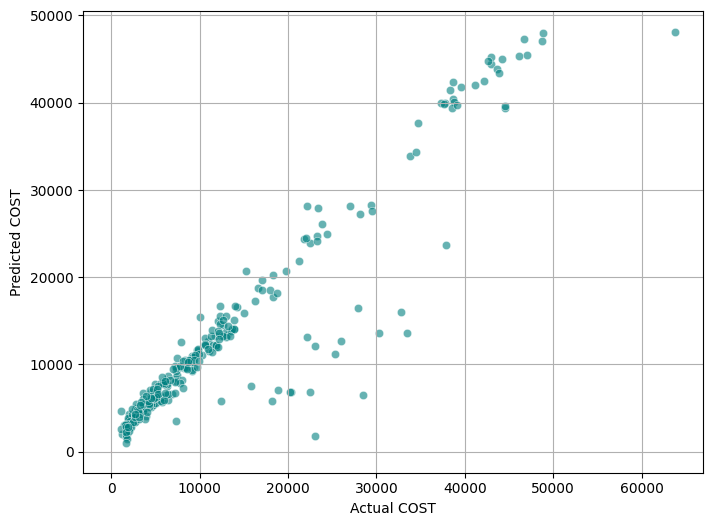

In [69]:
best_model_name = results_df.iloc[0]['Model']
best_model_obj = models[best_model_name]


#fit the best model

final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model',best_model_obj)
])

final_pipe.fit(X_train,y_train)
y_final_pred = final_pipe.predict(X_test)


#plot Actual vs predicted

plt.figure( figsize = (8,6) )

sns.scatterplot(x=y_test, y=y_final_pred, alpha = 0.6, color='teal' )
plt.plot( [2,5] , [2,5], color = "red", linestyle = '--'  )

plt.xlabel("Actual COST")
plt.ylabel("Predicted COST")

plt.grid(True)
plt.show()

In [70]:
from sklearn.model_selection import cross_val_score

In [83]:
gd_pipeline = Pipeline(
    [
        ('preprocessor',preprocessor),
        ('model',GradientBoostingRegressor(n_estimators=100,random_state=42))

     ]

  )

In [85]:

cv_scores = cross_val_score( gd_pipeline,X_train,y_train,cv=5, scoring='neg_mean_squared_error' )
cv_rmse = np.sqrt(-cv_scores)

print(cv_rmse)

[4852.91787787 3584.21467664 4810.59639119 5326.23619262 4852.01594743]


In [86]:
print(cv_rmse.mean())
print(cv_rmse.std())

4685.1962171488285
582.198794955105


In [87]:
param_grid = {
    'model__n_estimators' : [100,200] ,
    'model__max_depth': [None,10,20],
    'model__min_samples_split' : [2,5]
}

In [89]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator = gd_pipeline,
    param_grid = param_grid,
    cv = 5 ,
    scoring = 'neg_root_mean_squared_error',
    n_jobs =-1,
    verbose = 2

)

In [90]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'bmi',
                                                                          'children']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'smoker',
                                                                          'region',
                                                                          'bmi_category'])])),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [93]:
print("Best Params:", grid_search.best_params_)
print("Best Score:", -grid_search.best_score_)

Best Params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best Score: 5743.0377675568225


In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = y_final_pred # Use the predictions already made by the full pipeline

print("MAE:", mean_absolute_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
print("RMSE:", np.sqrt(mse))
print("R2:", r2_score(y_test, y_pred))

MAE: 2378.9845025146897
MSE: 18179242.340424944
RMSE: 4263.712272237063
R2: 0.8829024742054769
